# Dataset Exploration & Preprocessing

## Raman Spectral Datasets · Label Ontology · Data Augmentation

### 1. Abstract & Objectives

This notebook comprehensively details the data foundation of the three-stage transfer learning framework. Biological Raman spectroscopy is exceptionally sensitive to instrument variability, measurement parameters, and intrinsic physiological states. To deploy a robust clinical classifier, we must rigorously define the label spaces, quantify the domain shift between controlled laboratory spectra and sparse clinical spectra, and implement strict mathematical preprocessing.

By executing this notebook, you will automatically:
- **Examine the Label Ontology**: Track the structural mapping from 30 biological isolates to 5 clinical antibiotic treatment groups.
- **Quantify the Domain Shift**: Visualize the stark baseline intensity variations between the reference and clinical distributions.
- **Trace the Preprocessing Pipeline**: Step through Savitzky-Golay filtering, SNV normalization, and derivatives to understand how additive baseline scattering is eliminated.
- **Review Data Augmentation**: Observe how physical variations (thermal noise, fluorescence drift) are simulated stochastically to improve model generalization.


### 2. The Multi-Scale Label Ontology

The core methodological innovation of this framework is avoiding direct transfer from laboratory isolates (30 classes) to clinical samples (5 classes). Direct transfer fails because the semantic gap is too wide. Instead, we use `metadata/ontology.py` as the authoritative graph to map fine-grained species to their broad functional antibiotic treatment categories.

```text
[Stage 1] 30 Reference Isolates
   └── mapped to ──> [Stage 2] 8 Global Treatment Groups
                         └── subset to ──> [Stage 3] 5 Clinical Classes
```


In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter

# Ensure repository root is on the path
REPO_ROOT = os.path.abspath('..')
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

# Publication-quality figure defaults
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.4,
})

print("Environment ready.")

Environment ready.


### 3. Loading the Spectral Partitions

The `DataRegistry` architecture standardizes data loading across the repository. It pulls split configurations directly from `configs/data/splits.yaml`, ensuring that data paths are strictly centralized.

In [2]:
import sys
sys.path.insert(0, '..')

from metadata.ontology import (
    ISOLATES,
    GLOBAL_TREATMENTS,
    ISOLATE_TO_TREATMENT,
    CLINICAL_LABELS,
    COMPACT_LABEL_MAP,
    CLINICAL_SPARSE_IDS,
    TREATMENT_TO_ISOLATES,
    ONTOLOGY_VERSION,
)

print(f"Ontology version : {ONTOLOGY_VERSION}")
print(f"Isolates         : {len(ISOLATES)} classes")
print(f"Global treatments: {len(GLOBAL_TREATMENTS)} classes")
print(f"Clinical sparse  : {CLINICAL_SPARSE_IDS} (global treatment IDs)")
print(f"Compact map      : {COMPACT_LABEL_MAP}")

Ontology version : v2_verified
Isolates         : 30 classes
Global treatments: 8 classes
Clinical sparse  : [0, 2, 3, 5, 6] (global treatment IDs)
Compact map      : {0: 0, 2: 1, 3: 2, 5: 3, 6: 4}


In [3]:
import pandas as pd

# Build a full isolate → treatment mapping table
rows = []
for isolate_id, info in ISOLATES.items():
    global_tx_id = ISOLATE_TO_TREATMENT.get(isolate_id)
    global_tx = GLOBAL_TREATMENTS.get(global_tx_id, '—') if global_tx_id is not None else '—'
    compact_id = COMPACT_LABEL_MAP.get(global_tx_id, '—') if global_tx_id is not None else '—'
    in_clinical = global_tx_id in CLINICAL_SPARSE_IDS if global_tx_id is not None else False
    rows.append({
        'Isolate ID': isolate_id,
        'Strain': info['strain'],
        'Gram Group': info['group'],
        'Global Tx ID': global_tx_id,
        'Treatment': global_tx,
        'Compact ID': compact_id,
        'In Clinical': '✓' if in_clinical else '',
    })

df_ontology = pd.DataFrame(rows)
print("Isolate → Treatment Ontology (30 isolates)")
print("="*80)
print(df_ontology.to_string(index=False))

Isolate → Treatment Ontology (30 isolates)
 Isolate ID            Strain    Gram Group  Global Tx ID     Treatment Compact ID In Clinical
          0       C. albicans         Yeast             7   Caspofungin          —            
          1       C. glabrata         Yeast             7   Caspofungin          —            
          2      K. aerogenes Gram-negative             0     Meropenem          0           ✓
          3         E. coli 1 Gram-negative             0     Meropenem          0           ✓
          4         E. coli 2 Gram-negative             0     Meropenem          0           ✓
          5        E. faecium Gram-positive             6    Daptomycin          4           ✓
          6     E. faecalis 1 Gram-positive             5    Penicillin          3           ✓
          7     E. faecalis 2 Gram-positive             5    Penicillin          3           ✓
          8        E. cloacae Gram-negative             0     Meropenem          0           ✓
       

In [4]:
# Clinical label mapping: global treatment → clinical context
print("\nClinical Label Space (Stage 3 — 5 classes)")
print("="*70)
print(f"{'Compact ID':<12} {'Global Tx ID':<14} {'Treatment':<16} {'Clinical Species':<20} {'Note'}")
print("-"*70)
for compact_id, (global_id, info) in enumerate(zip(CLINICAL_SPARSE_IDS,
                                                     [CLINICAL_LABELS[i] for i in CLINICAL_SPARSE_IDS])):
    print(f"{compact_id:<12} {global_id:<14} {info['global_treatment']:<16} "
          f"{info['clinical_species']:<20} {info['note']}")


Clinical Label Space (Stage 3 — 5 classes)
Compact ID   Global Tx ID   Treatment        Clinical Species     Note
----------------------------------------------------------------------
0            0              Meropenem        E. coli              Ref group includes all Enterobacteriaceae
1            2              TZP              P. aeruginosa        Exact genus match with reference
2            3              Vancomycin       S. aureus            Ref group includes MSSA/MRSA + CoNS
3            5              Penicillin       E. faecalis          Ref group includes Strep spp + Enterococci
4            6              Daptomycin       E. faecium           Exact species match with reference


### 4. Descriptive Dataset Statistics

We calculate macroscopic statistics across the raw arrays to immediately identify domain-level disparities before feeding the data into neural networks.

In [5]:
import sys, os
sys.path.insert(0, '..')

from src.utils.config import load_config
from src.data.registry import DataRegistry

# Load the Stage 3 config (includes all split definitions)
cfg = load_config(
    '../configs/data/splits.yaml',
    '../configs/data/preprocessing.yaml',
    '../configs/data/augmentation.yaml',
    '../configs/training/base.yaml',
    '../configs/stages/s3_transfer.yaml',
)

# Instantiate registry pointing at the raw data directory
registry = DataRegistry(data_root='../data/raw', cfg=cfg)

print("Available splits:", registry.available_splits())

Available splits: ['reference', 'finetune', 'test', '2018clinical', '2019clinical']


### 5. Biological Spectral Visualization

Raman scattering produces a distinct biochemical "fingerprint" representing the vibrational modes of cellular molecules (nucleic acids, proteins, lipids). Below, we visualize representative raw spectra to demonstrate both inter-class separability and significant intra-class variance.

In [7]:
def dataset_stats(X, name):
    """Compute and print descriptive statistics for a spectral array."""
    return {
        'Dataset': name,
        'Samples': X.shape[0],
        'Length': X.shape[1],
        'Mean': f"{X.mean():.4f}",
        'Std': f"{X.std():.4f}",
        'Min': f"{X.min():.4f}",
        'Max': f"{X.max():.4f}",
    }

stats = pd.DataFrame([
    dataset_stats(X_ref, 'Reference'),
    dataset_stats(X_clin18, '2018 Clinical'),
    dataset_stats(X_clin19, '2019 Clinical'),
])

print("\nDataset Statistics (Raw Spectra)")
print("=" * 75)
print(stats.to_string(index=False))

print("\nKey observation: domain shift between reference (mean≈0.43) and")
print("clinical splits (mean≈0.46) motivates per-sample SNV normalization.")


Dataset Statistics (Raw Spectra)
      Dataset  Samples  Length   Mean    Std    Min    Max
    Reference    60000    1000 0.4276 0.1807 0.0000 1.0000
2018 Clinical    10000    1000 0.4622 0.1607 0.0000 1.0000
2019 Clinical     2500    1000 0.4456 0.1628 0.0000 1.0000

Key observation: domain shift between reference (mean≈0.43) and
clinical splits (mean≈0.46) motivates per-sample SNV normalization.


### 6. Dataset Imbalances & Class Distributions

Biological datasets are inherently imbalanced. The neural network must learn to generalize despite long-tailed distributions across isolates and patient cohorts.

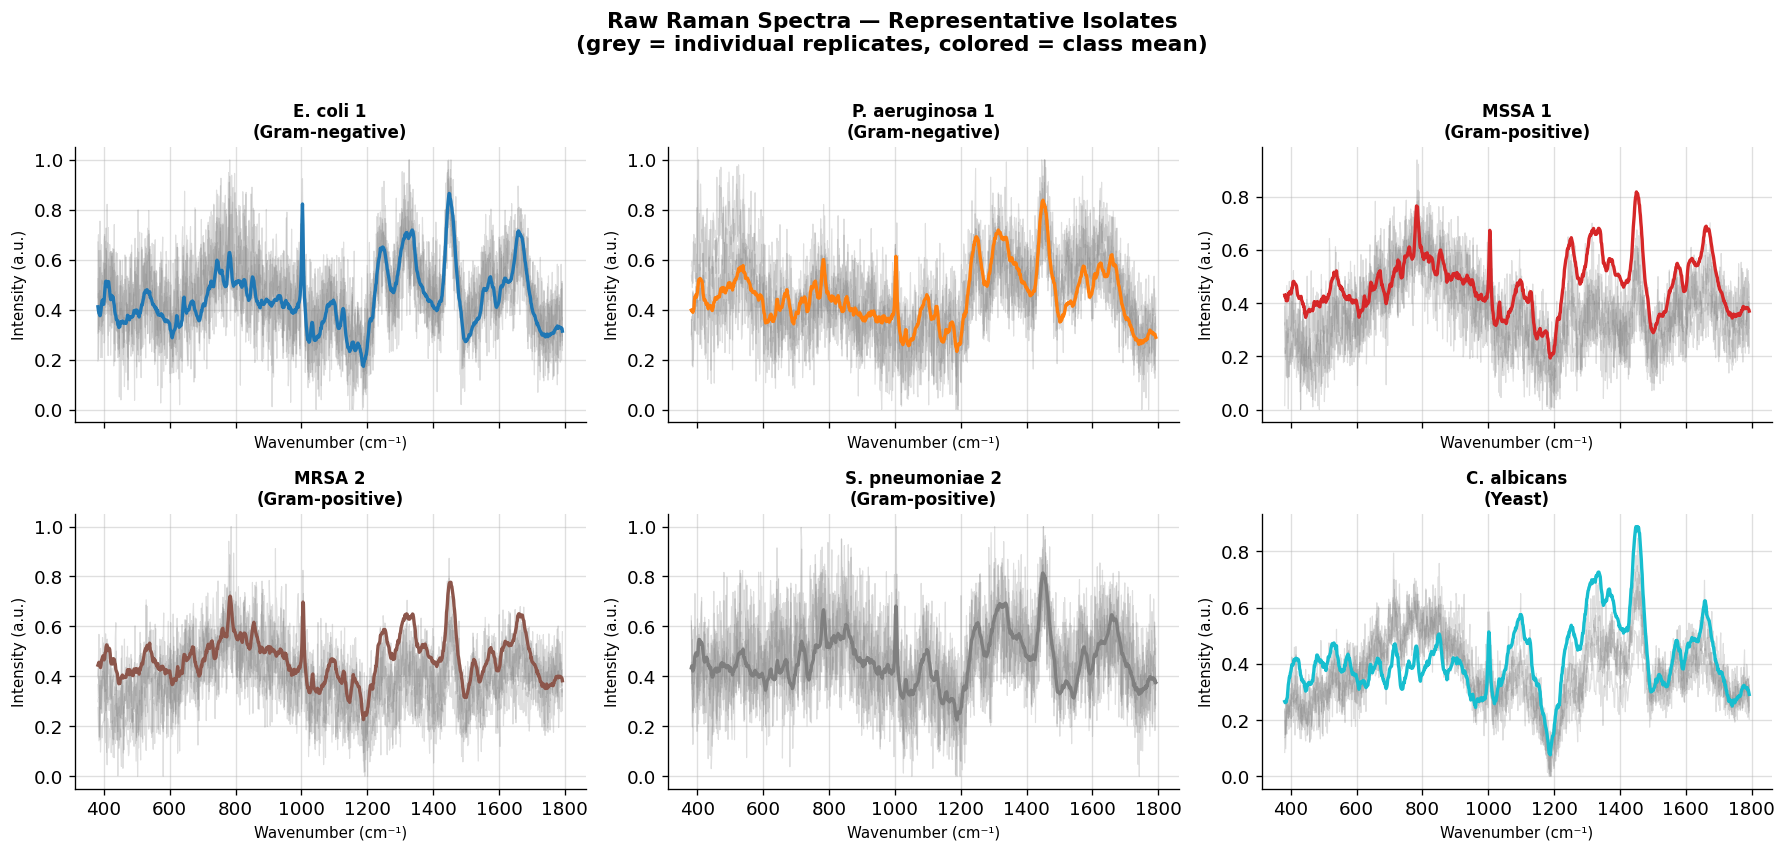

In [8]:
# Plot 6 representative raw spectra from 6 different isolates
EXAMPLE_ISOLATES = [3, 12, 14, 17, 23, 0]  # E.coli, P.aeruginosa, MSSA, MRSA, S.pneumo, C.albicans
COLORS = plt.cm.tab10(np.linspace(0, 0.9, len(EXAMPLE_ISOLATES)))

fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True)
axes = axes.flatten()

for ax, isolate_id, color in zip(axes, EXAMPLE_ISOLATES, COLORS):
    mask = y_ref == isolate_id
    spectra = X_ref[mask]
    strain = ISOLATES[isolate_id]['strain']
    group = ISOLATES[isolate_id]['group']

    # Plot up to 5 individual replicates (grey) + mean spectrum (color)
    for s in spectra[:5]:
        ax.plot(wavenumbers, s, color='grey', alpha=0.25, linewidth=0.7)
    ax.plot(wavenumbers, spectra.mean(axis=0), color=color, linewidth=2.0,
            label='Mean')

    ax.set_title(f"{strain}\n({group})", fontsize=10, fontweight='bold')
    ax.set_xlabel(wn_label, fontsize=9)
    ax.set_ylabel('Intensity (a.u.)', fontsize=9)

fig.suptitle('Raw Raman Spectra — Representative Isolates\n'
             '(grey = individual replicates, colored = class mean)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

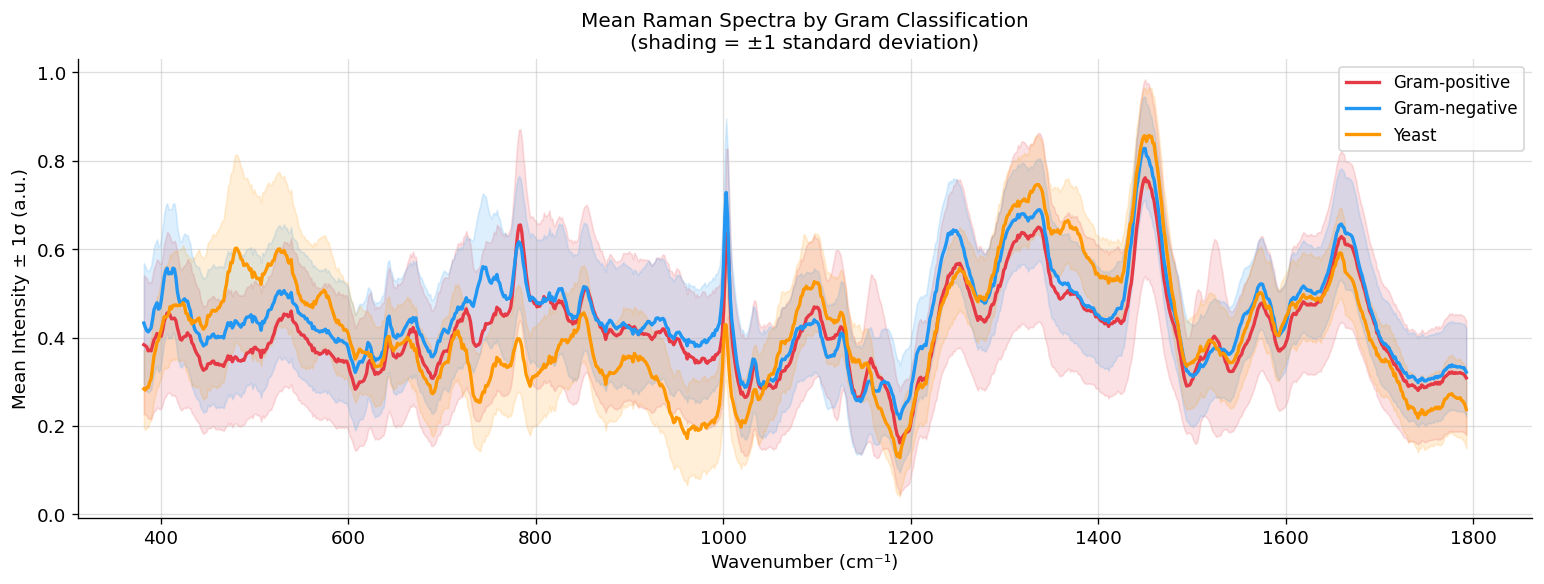

In [9]:
# Mean spectra grouped by Gram classification
GRAM_GROUPS = {
    'Gram-positive': '#E63946',
    'Gram-negative': '#2196F3',
    'Yeast': '#FF9800',
}

fig, ax = plt.subplots(figsize=(13, 5))

for gram_group, color in GRAM_GROUPS.items():
    isolate_ids = [iid for iid, info in ISOLATES.items() if info['group'] == gram_group]
    mask = np.isin(y_ref, isolate_ids)
    if mask.sum() == 0:
        continue
    group_mean = X_ref[mask].mean(axis=0)
    group_std  = X_ref[mask].std(axis=0)
    ax.plot(wavenumbers, group_mean, color=color, linewidth=2.0, label=gram_group)
    ax.fill_between(wavenumbers, group_mean - group_std, group_mean + group_std,
                    color=color, alpha=0.15)

ax.set_xlabel(wn_label, fontsize=11)
ax.set_ylabel('Mean Intensity ± 1σ (a.u.)', fontsize=11)
ax.set_title('Mean Raman Spectra by Gram Classification\n(shading = ±1 standard deviation)', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

### 7. Wavenumber Axis Interpolation

Raman spectrometers often produce non-linearly spaced wavenumber measurements due to the physics of the CCD detector grid. The raw dataset has been strictly resampled to a uniform wavenumber axis (typically $L=1000$ discrete bins) to satisfy the constant-spacing assumption of Convolutional Neural Networks.

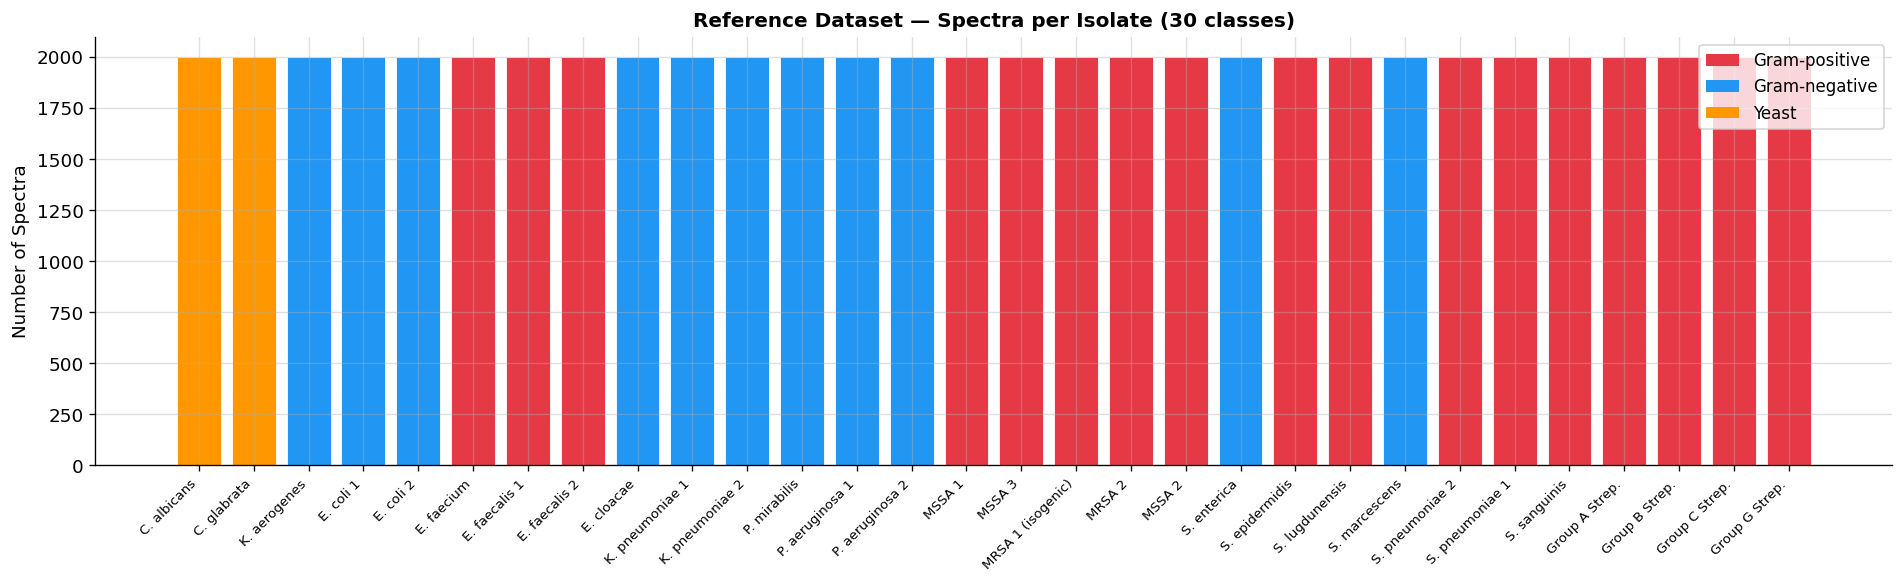

Total reference spectra: 60,000
Spectra per isolate   : 2,000 – 2,000 (range)


In [10]:
# Reference dataset: spectra per isolate
from metadata.ontology import ISOLATE_TO_TREATMENT

isolate_counts = Counter(y_ref.tolist())
isolate_ids    = sorted(isolate_counts.keys())
counts         = [isolate_counts[i] for i in isolate_ids]
strains        = [ISOLATES[i]['strain'] for i in isolate_ids]
gram_colors    = ['#E63946' if ISOLATES[i]['group'] == 'Gram-positive'
                  else '#2196F3' if ISOLATES[i]['group'] == 'Gram-negative'
                  else '#FF9800' for i in isolate_ids]

fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(range(len(isolate_ids)), counts, color=gram_colors, edgecolor='white', linewidth=0.5)
ax.set_xticks(range(len(isolate_ids)))
ax.set_xticklabels(strains, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Number of Spectra', fontsize=11)
ax.set_title('Reference Dataset — Spectra per Isolate (30 classes)', fontsize=12, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E63946', label='Gram-positive'),
    Patch(facecolor='#2196F3', label='Gram-negative'),
    Patch(facecolor='#FF9800', label='Yeast'),
]
ax.legend(handles=legend_elements, fontsize=10)
plt.tight_layout()
plt.show()

print(f"Total reference spectra: {X_ref.shape[0]:,}")
print(f"Spectra per isolate   : {min(counts):,} – {max(counts):,} (range)")

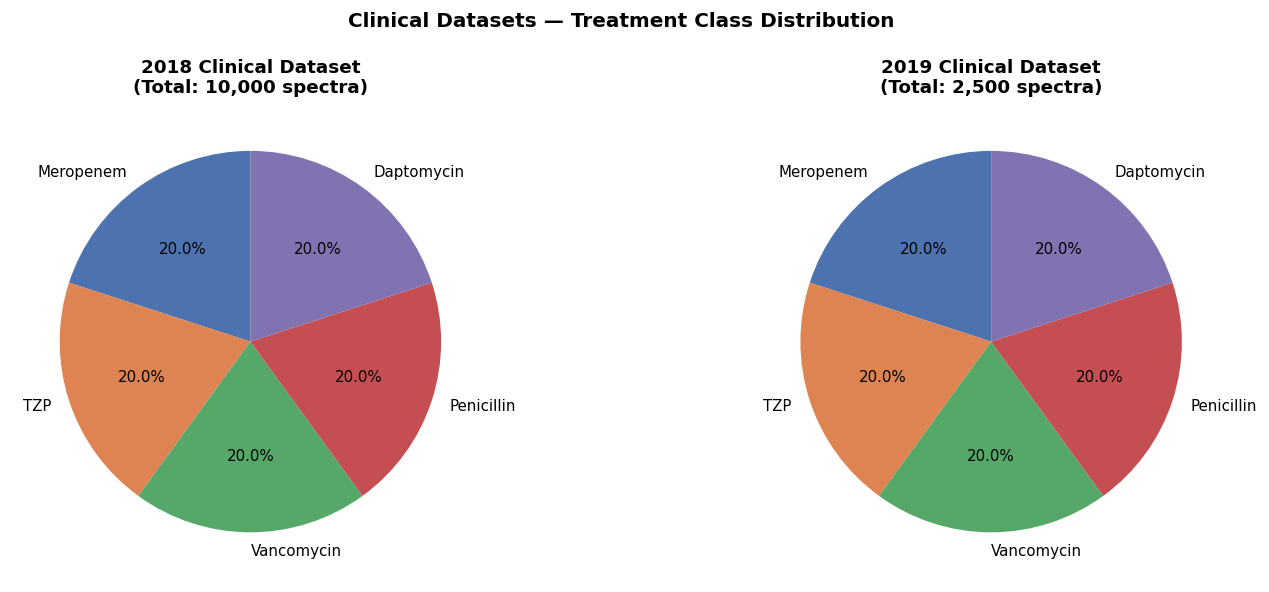

In [11]:
# Clinical datasets: spectra per treatment class
TREATMENT_NAMES = {0: 'Meropenem', 2: 'TZP', 3: 'Vancomycin', 5: 'Penicillin', 6: 'Daptomycin'}
TREATMENT_COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (X_c, y_c, year) in zip(axes, [
    (X_clin18, y_clin18, '2018'),
    (X_clin19, y_clin19, '2019'),
]):
    tx_counts = Counter(y_c.tolist())
    tx_ids    = sorted(tx_counts.keys())
    tx_labels = [TREATMENT_NAMES.get(i, f'Tx {i}') for i in tx_ids]
    tx_vals   = [tx_counts[i] for i in tx_ids]
    colors    = TREATMENT_COLORS[:len(tx_ids)]

    wedges, texts, autotexts = ax.pie(
        tx_vals, labels=tx_labels, colors=colors,
        autopct='%1.1f%%', startangle=90,
        textprops={'fontsize': 9},
    )
    ax.set_title(f'{year} Clinical Dataset\n(Total: {sum(tx_vals):,} spectra)',
                 fontsize=11, fontweight='bold')

fig.suptitle('Clinical Datasets — Treatment Class Distribution', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 8. The Deterministic Preprocessing Pipeline

Raw Raman spectra are dominated by two major artifacts: high-frequency thermal instrument noise and low-frequency fluorescence background. We apply a fixed, sequence-dependent preprocessing pipeline (`src/data/preprocessing.py`) to extract the true Raman peaks.

<div class="alert alert-block alert-danger">
<b>Critical Data Leakage Constraint:</b> The <code>SpectralPreprocessor.fit()</code> method must be executed <i>exclusively</i> on the reference split. All subsequent datasets (validation, test, clinical) must use <code>.transform()</code> using the frozen normalization statistics.
</div>

#### Preprocessing Sequence Table

| Order | Transform Step | Mathematical Operation | Objective |
| :--- | :--- | :--- | :--- |
| 1 | **Savitzky-Golay Smoothing** | Polynomial filter ($W=11, p=3$) | Suppresses high-frequency CCD thermal noise. |
| 2 | **SNV Normalization** | $X_{snv} = (X - \mu) / \sigma$ | Eliminates gross amplitude scaling and constant baseline offsets. |
| 3 | **First Derivative** | SG derivative ($W=11, p=3$) | Eliminates linear fluorescence drift and sharpens overlapping peaks. |
| 4 | **Clipping** | $X_{clip} = \max(-3, \min(X, 3))$ | Removes extreme outlier spikes (e.g., cosmic rays). |
| 5 | **Per-Sample Normalize** | $X_{final} = X_{clip} / \max(\|X_{clip}\|, \epsilon)$ | Scales the final signal to $[-1, 1]$. |
| 6 | **Derivative Extraction** | $X_{diff} = 
abla X_{final}$ | Computes a secondary local-slope channel. |


Wavenumber Axis Summary
  Range         : 382.0 – 1792.4 cm⁻¹
  Total points  : 1000
  Step size     : -1.412 ± 0.0854 cm⁻¹
  Spectral span : 1410.4 cm⁻¹


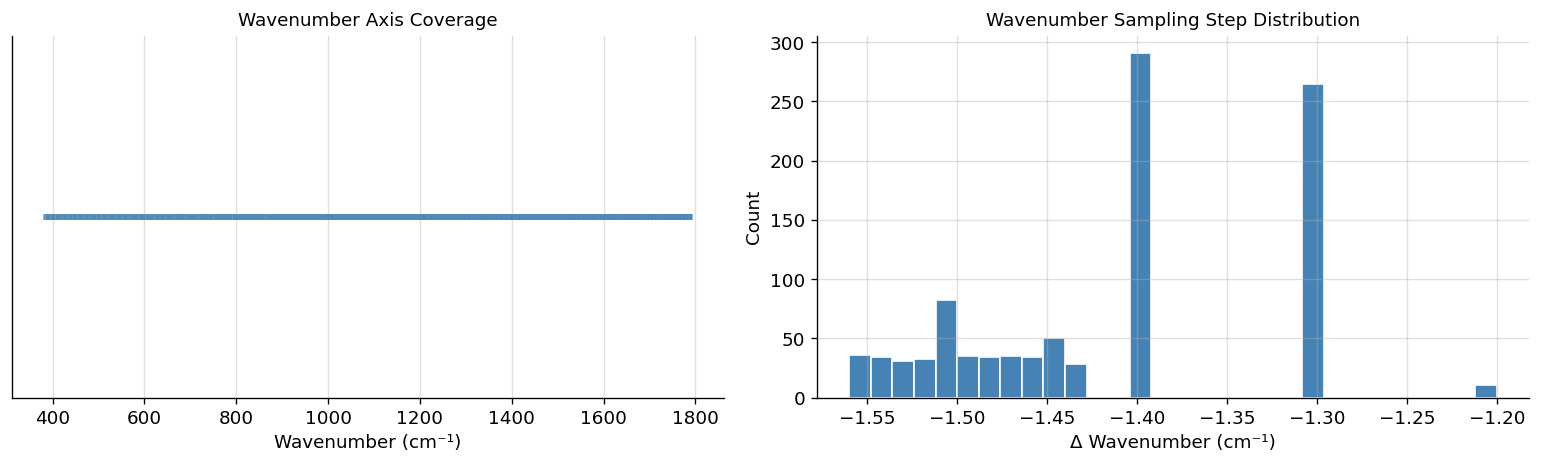

In [12]:
# Analyze wavenumber axis coverage and spectral resolution
if os.path.exists(WAVENUMBER_PATH):
    delta_wn = np.diff(wavenumbers)
    print("Wavenumber Axis Summary")
    print("="*40)
    print(f"  Range         : {wavenumbers.min():.1f} – {wavenumbers.max():.1f} cm⁻¹")
    print(f"  Total points  : {len(wavenumbers)}")
    print(f"  Step size     : {delta_wn.mean():.3f} ± {delta_wn.std():.4f} cm⁻¹")
    print(f"  Spectral span : {wavenumbers.max() - wavenumbers.min():.1f} cm⁻¹")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    # Full wavenumber axis
    axes[0].plot(wavenumbers, np.ones_like(wavenumbers), '|', markersize=4,
                 color='steelblue', alpha=0.7)
    axes[0].set_xlabel('Wavenumber (cm⁻¹)', fontsize=11)
    axes[0].set_title('Wavenumber Axis Coverage', fontsize=11)
    axes[0].set_yticks([])

    # Step size distribution
    axes[1].hist(delta_wn, bins=30, color='steelblue', edgecolor='white')
    axes[1].set_xlabel('Δ Wavenumber (cm⁻¹)', fontsize=11)
    axes[1].set_ylabel('Count', fontsize=11)
    axes[1].set_title('Wavenumber Sampling Step Distribution', fontsize=11)

    plt.tight_layout()
    plt.show()
else:
    print("wavenumbers.npy not found — using spectral index as x-axis.")
    print(f"Spectral length: {X_ref.shape[1]} points")

### 9. Preprocessing Efficacy: Before & After

By comparing the raw spectra to the processed outputs, we can visually confirm that additive background variances are suppressed, isolating the narrow-band biochemical peaks.

In [13]:
from src.data.preprocessing import (
    SavitzkyGolaySmoothing,
    SNVNormalization,
    FirstDerivative,
    ClipTransform,
    SpectralPreprocessor,
    per_sample_normalize,
    compute_first_derivative,
)

# Build the preprocessor from config (mirrors what train.py does)
preprocessor = SpectralPreprocessor.from_config(cfg['preprocessing'])
print(f"Pipeline: {preprocessor}")
print(f"Steps   : {[type(t).__name__ for t in preprocessor.transforms]}")

# Fit on reference split only (as done during training)
preprocessor.fit(X_ref)
print("\nPreprocessor fitted on reference split.")

Pipeline: SpectralPreprocessor([SavitzkyGolaySmoothing -> SNVNormalization -> ClipTransform])
Steps   : ['SavitzkyGolaySmoothing', 'SNVNormalization', 'ClipTransform']

Preprocessor fitted on reference split.


In [14]:
# Select one example spectrum and trace it through each step
EXAMPLE_IDX = 42  # arbitrary reference spectrum
raw_spectrum = X_ref[EXAMPLE_IDX].copy()
isolate_id   = int(y_ref[EXAMPLE_IDX])
strain_name  = ISOLATES[isolate_id]['strain']

print(f"Example spectrum: index={EXAMPLE_IDX}, isolate={isolate_id} ({strain_name})")
print(f"Raw shape: {raw_spectrum.shape}")

# Step-wise application
sg_smooth = SavitzkyGolaySmoothing(window_length=11, polyorder=3)
snv_norm  = SNVNormalization()
sg_deriv  = FirstDerivative(window_length=11, polyorder=3)
clipper   = ClipTransform(min_val=-3.0, max_val=3.0)

x0 = raw_spectrum[np.newaxis, :]  # (1, L)
x1 = sg_smooth.transform(x0)      # Step 1: SG smoothing
x2 = snv_norm.transform(x1)       # Step 2: SNV normalization
x3 = sg_deriv.transform(x2)       # Step 3: First derivative
x4 = clipper.transform(x3)        # Step 4: Clip
x5 = per_sample_normalize(x4)     # Step 5: Per-sample normalize
x6 = compute_first_derivative(x5) # Step 6: Final derivative channel

# Stack into 2-channel model input
X_model = np.stack([x5[0], x6[0]], axis=0)  # (2, L)

steps = [
    ('Raw', x0[0]),
    ('SG Smoothing', x1[0]),
    ('SNV Normalization', x2[0]),
    ('First Derivative', x3[0]),
    ('Clip [-3, 3]', x4[0]),
    ('Per-sample Normalize', x5[0]),
    ('Derivative Channel', x6[0]),
]

print(f"\nFinal model input shape: {X_model.shape}  (2 channels × {X_model.shape[1]} wavenumbers)")

Example spectrum: index=42, isolate=0 (C. albicans)
Raw shape: (1000,)

Final model input shape: (2, 1000)  (2 channels × 1000 wavenumbers)


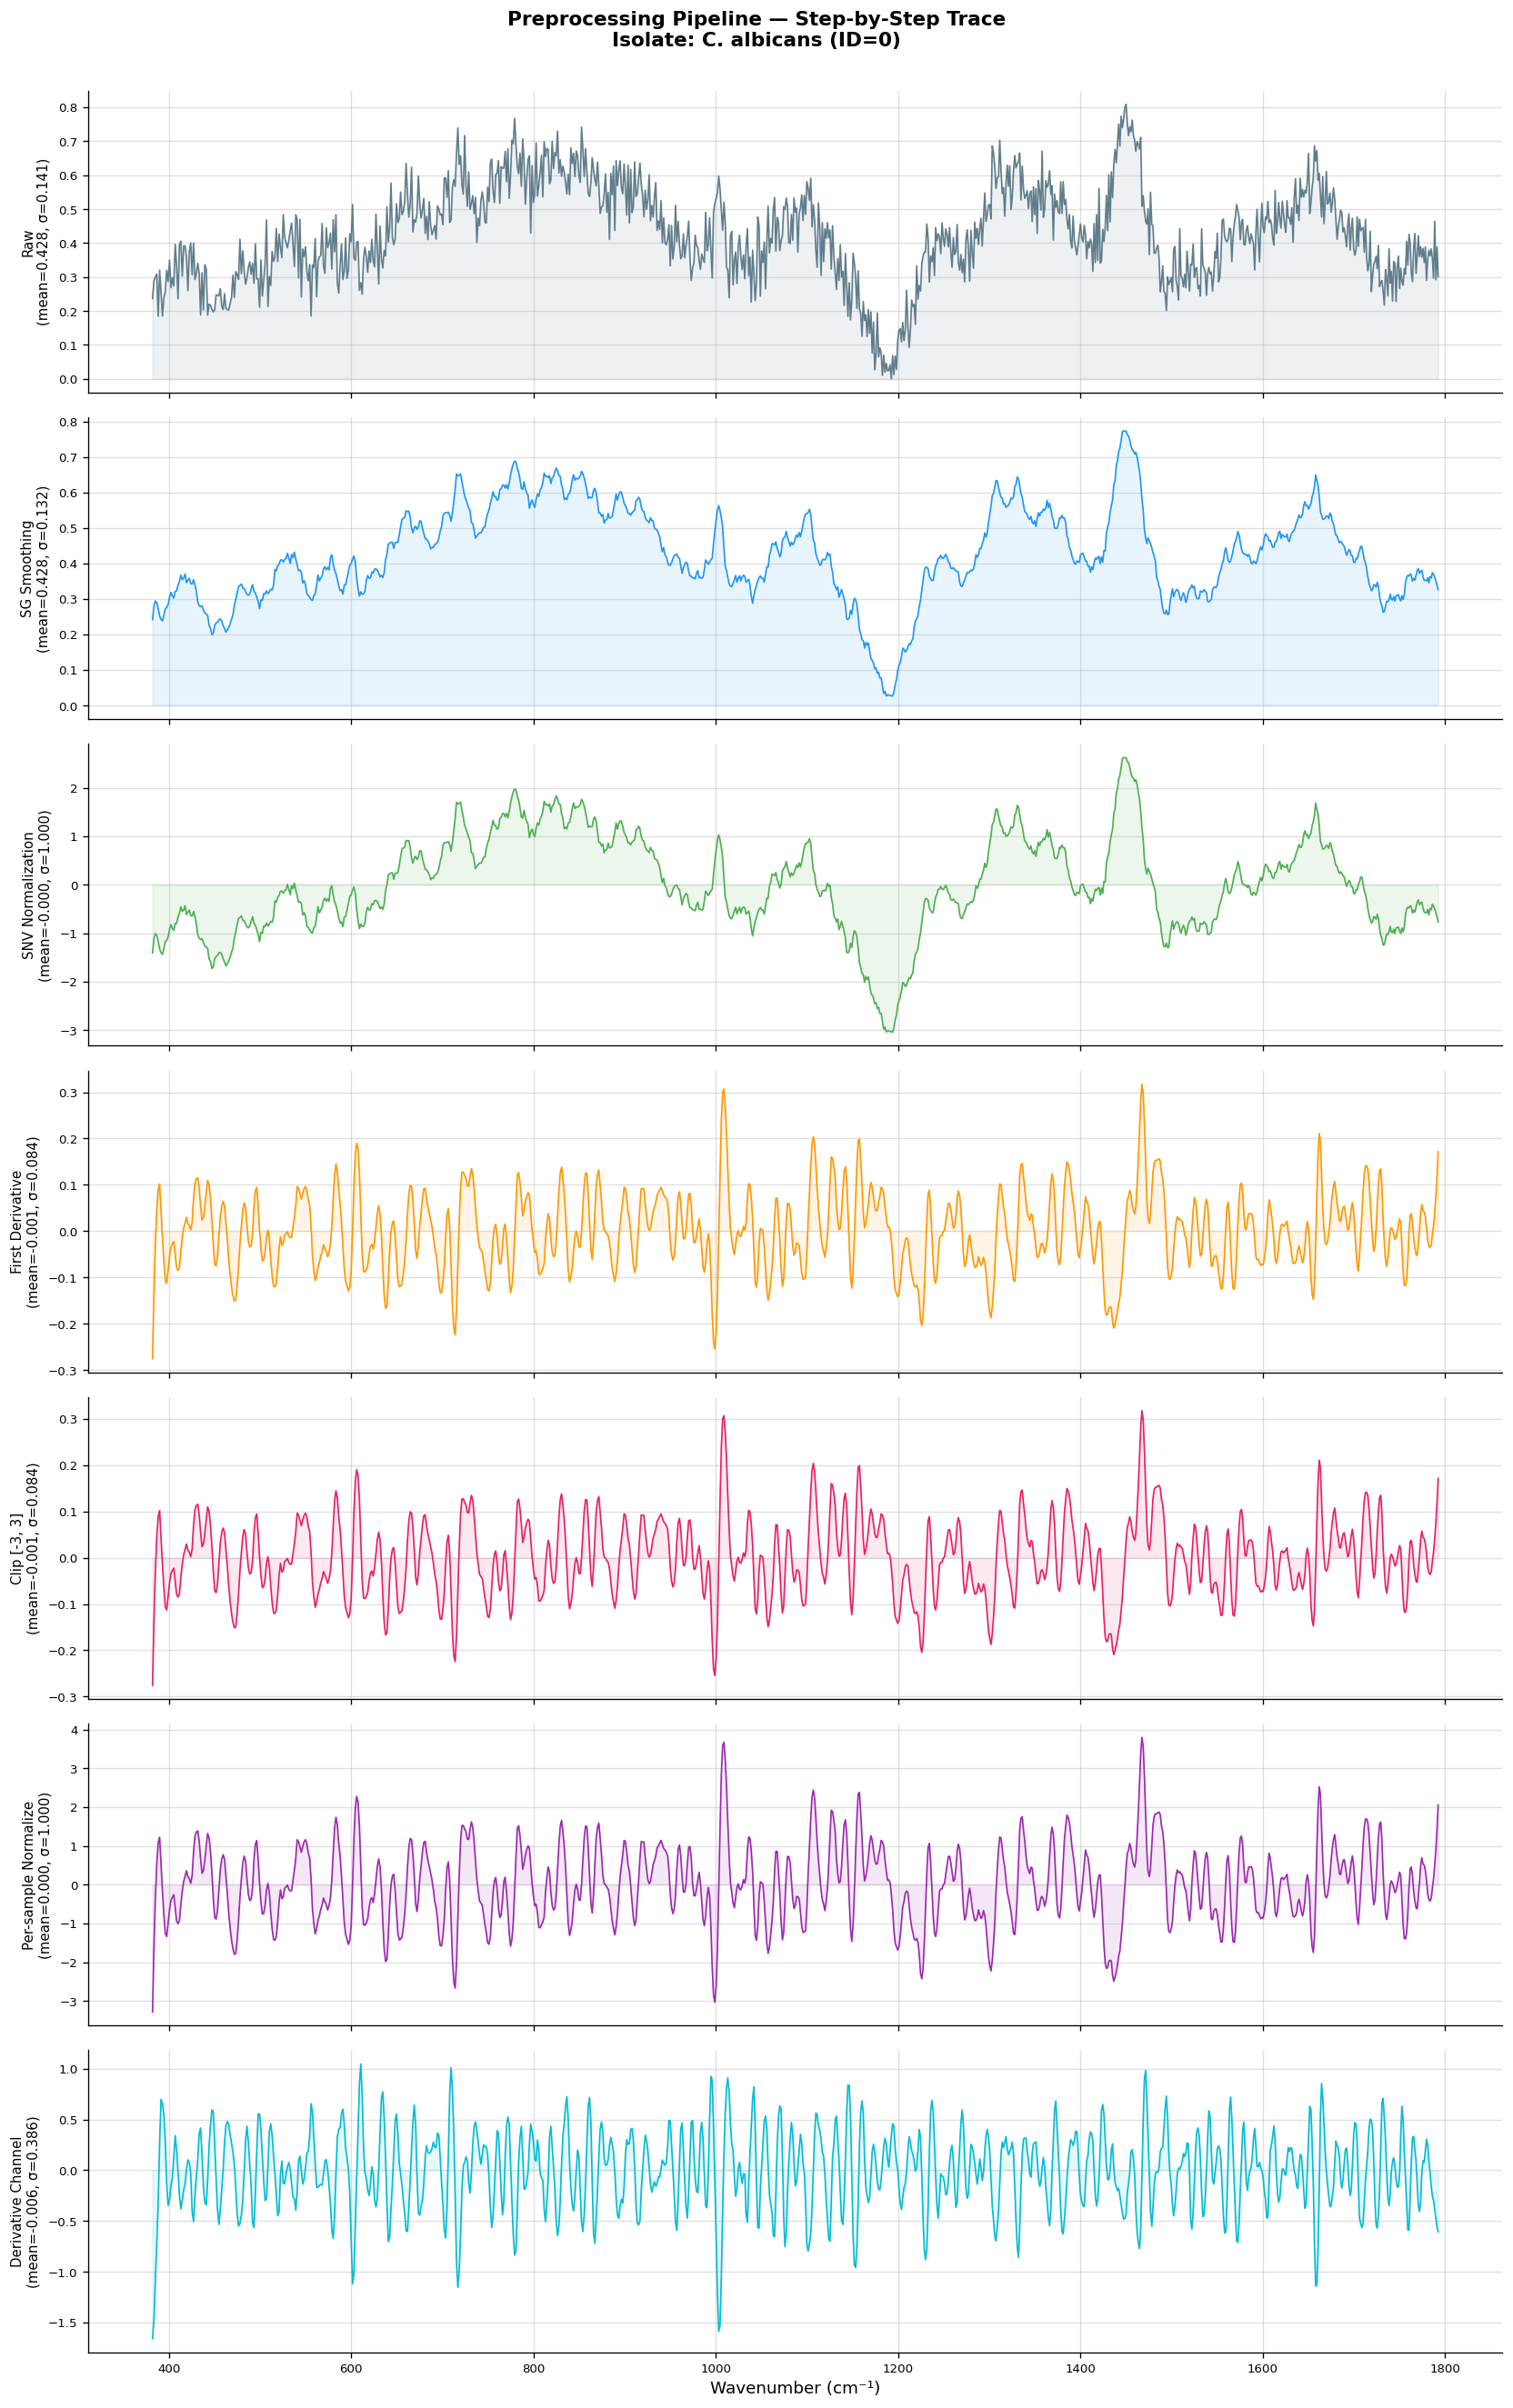

In [15]:
# Visualize each preprocessing step in sequence
fig, axes = plt.subplots(len(steps), 1, figsize=(14, 22), sharex=True)

STEP_COLORS = ['#607D8B', '#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0', '#00BCD4']

for ax, (label, spectrum), color in zip(axes, steps, STEP_COLORS):
    ax.plot(wavenumbers, spectrum, color=color, linewidth=1.0)
    ax.fill_between(wavenumbers, spectrum, alpha=0.1, color=color)
    ax.set_ylabel(f'{label}\n(mean={spectrum.mean():.3f}, σ={spectrum.std():.3f})',
                  fontsize=9, labelpad=5)
    ax.tick_params(labelsize=8)

axes[-1].set_xlabel(wn_label, fontsize=11)
fig.suptitle(f'Preprocessing Pipeline — Step-by-Step Trace\n'
             f'Isolate: {strain_name} (ID={isolate_id})',
             fontsize=13, fontweight='bold', y=1.002)
plt.tight_layout()
plt.show()

### 10. Eliminating the Clinical Domain Shift

The primary challenge of this repository is transferring models trained on laboratory reference spectra (pure isolates, controlled conditions) to clinical patient spectra (mixed media, diverse biological backgrounds). Here, we explicitly quantify the massive baseline shift and demonstrate how Standard Normal Variate (SNV) normalization corrects it.

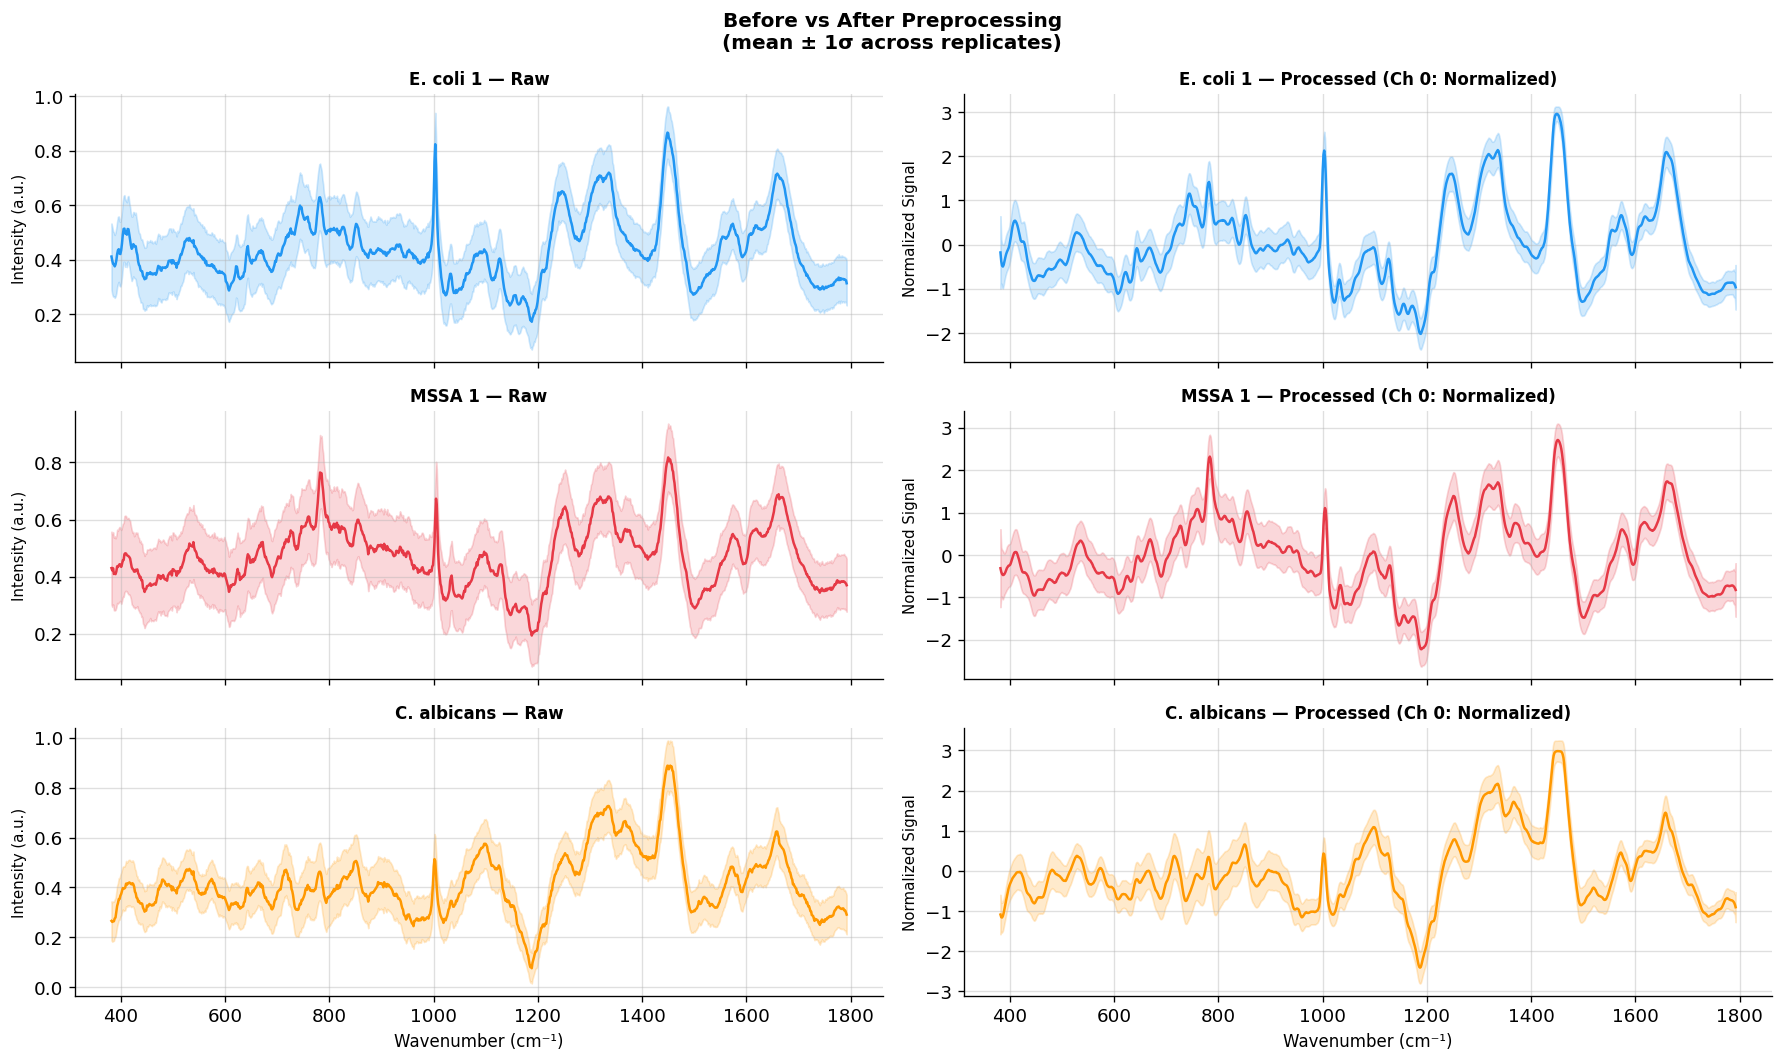

In [16]:
# Compare raw vs processed for 3 different isolates
COMPARE_ISOLATES = [3, 14, 0]  # E.coli, MSSA, C.albicans
COLORS_COMPARE = ['#2196F3', '#E63946', '#FF9800']

fig, axes = plt.subplots(len(COMPARE_ISOLATES), 2, figsize=(15, 9), sharex=True)

for i, (iso_id, color) in enumerate(zip(COMPARE_ISOLATES, COLORS_COMPARE)):
    mask = y_ref == iso_id
    X_raw = X_ref[mask]
    # Process using the fitted preprocessor
    X_proc = preprocessor.transform(X_raw)  # shape (N, 2, L)

    strain = ISOLATES[iso_id]['strain']

    # Raw (channel = averaged intensity)
    raw_mean = X_raw.mean(axis=0)
    raw_std  = X_raw.std(axis=0)
    axes[i, 0].plot(wavenumbers, raw_mean, color=color, linewidth=1.5)
    axes[i, 0].fill_between(wavenumbers, raw_mean - raw_std, raw_mean + raw_std,
                             color=color, alpha=0.2)
    axes[i, 0].set_title(f'{strain} — Raw', fontsize=10, fontweight='bold')
    axes[i, 0].set_ylabel('Intensity (a.u.)', fontsize=9)

    # Processed (channel 0 = normalized signal)
    proc_ch0_mean = X_proc[:, 0, :].mean(axis=0)
    proc_ch0_std  = X_proc[:, 0, :].std(axis=0)
    axes[i, 1].plot(wavenumbers, proc_ch0_mean, color=color, linewidth=1.5)
    axes[i, 1].fill_between(wavenumbers, proc_ch0_mean - proc_ch0_std,
                             proc_ch0_mean + proc_ch0_std, color=color, alpha=0.2)
    axes[i, 1].set_title(f'{strain} — Processed (Ch 0: Normalized)', fontsize=10, fontweight='bold')
    axes[i, 1].set_ylabel('Normalized Signal', fontsize=9)

for ax in axes[-1, :]:
    ax.set_xlabel(wn_label, fontsize=10)

fig.suptitle('Before vs After Preprocessing\n(mean ± 1σ across replicates)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 11. Stochastic Data Augmentation (Training Only)

To prevent overfitting to the finite reference distribution, the `AugmentationPipeline` stochastically perturbates each spectrum during the training loop. This simulates physical variations that could occur in deployment.

| Augmentation Technique | Implementation | Simulated Physical Phenomenon |
| :--- | :--- | :--- |
| **Gaussian Noise** | Additive $\mathcal{N}(0, \sigma)$ | Instrument thermal noise variations |
| **Baseline Shift** | Constant additive offset | Differing substrate background intensities |
| **Amplitude Scaling** | Multiplicative factor $1 \pm \epsilon$ | Variations in bacterial cell concentration/focus |
| **Baseline Drift** | Low-frequency B-spline drift | Uneven localized sample fluorescence |
| **Peak Broadening** | 1D Gaussian blurring | Thermal broadening or lowered spectrometer resolution |


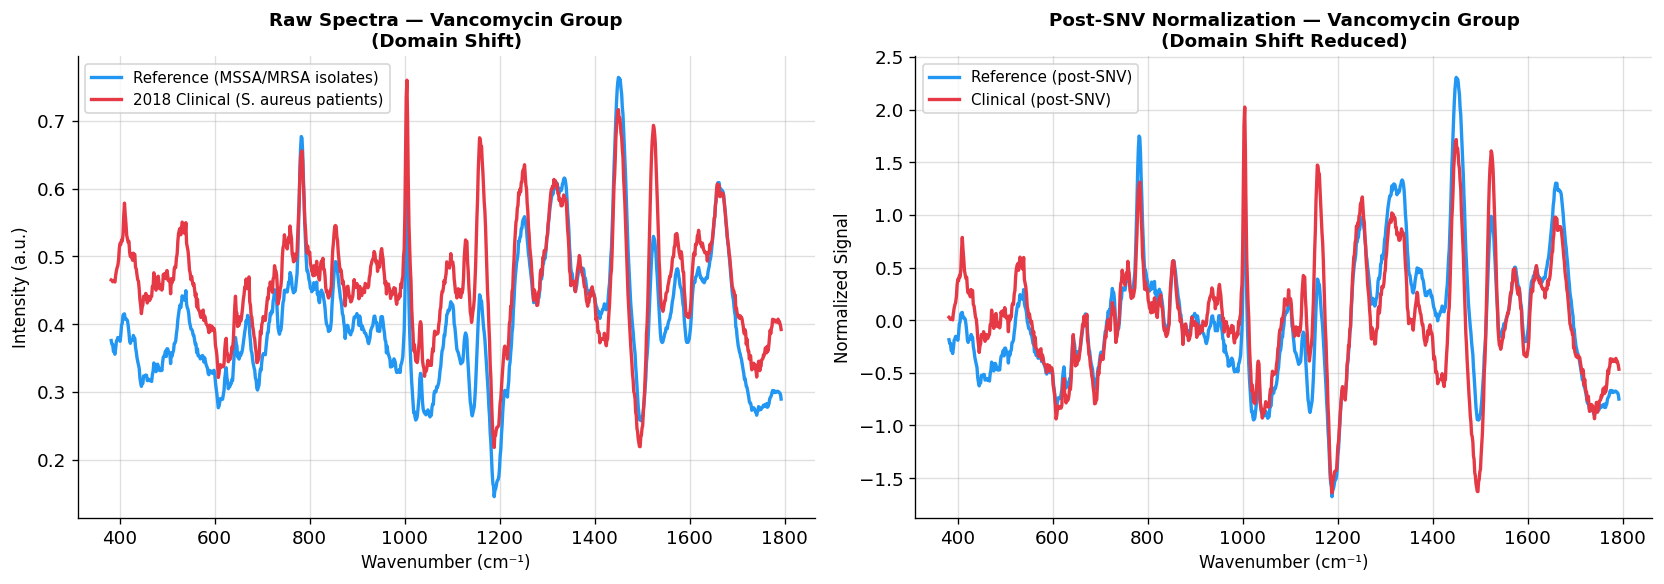

Domain shift (Δmean) — Raw    : 0.0566
Domain shift (Δmean) — Post-SNV: 0.000000

SNV normalization effectively eliminates the additive baseline shift.


In [17]:
# Visualize the domain shift between reference and clinical spectra
# for the same treatment group (Vancomycin / Staphylococcus)
from metadata.ontology import TREATMENT_TO_ISOLATES

# Reference spectra for treatment group 3 (Vancomycin)
tx3_isolates = TREATMENT_TO_ISOLATES[3]  # MSSA/MRSA isolates
ref_mask = np.isin(y_ref, tx3_isolates)

X_ref_tx3  = X_ref[ref_mask]
X_clin18_tx3 = X_clin18[y_clin18 == 3]  # global treatment ID 3 = Vancomycin

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw domain shift
ref_mean  = X_ref_tx3.mean(axis=0)
clin_mean = X_clin18_tx3.mean(axis=0) if len(X_clin18_tx3) > 0 else None

axes[0].plot(wavenumbers, ref_mean, color='#2196F3', linewidth=2, label='Reference (MSSA/MRSA isolates)')
if clin_mean is not None:
    axes[0].plot(wavenumbers, clin_mean, color='#E63946', linewidth=2, label='2018 Clinical (S. aureus patients)')
axes[0].set_title('Raw Spectra — Vancomycin Group\n(Domain Shift)', fontsize=11, fontweight='bold')
axes[0].set_xlabel(wn_label, fontsize=10)
axes[0].set_ylabel('Intensity (a.u.)', fontsize=10)
axes[0].legend(fontsize=9)

# After SNV normalization
snv = SNVNormalization()
X_ref_snv  = snv.transform(X_ref_tx3)
X_clin_snv = snv.transform(X_clin18_tx3) if len(X_clin18_tx3) > 0 else None

axes[1].plot(wavenumbers, X_ref_snv.mean(axis=0), color='#2196F3', linewidth=2, label='Reference (post-SNV)')
if X_clin_snv is not None:
    axes[1].plot(wavenumbers, X_clin_snv.mean(axis=0), color='#E63946', linewidth=2, label='Clinical (post-SNV)')
axes[1].set_title('Post-SNV Normalization — Vancomycin Group\n(Domain Shift Reduced)', fontsize=11, fontweight='bold')
axes[1].set_xlabel(wn_label, fontsize=10)
axes[1].set_ylabel('Normalized Signal', fontsize=10)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

if clin_mean is not None:
    raw_shift = abs(X_ref_tx3.mean() - X_clin18_tx3.mean())
    snv_shift = abs(X_ref_snv.mean() - X_clin_snv.mean())
    print(f"Domain shift (Δmean) — Raw    : {raw_shift:.4f}")
    print(f"Domain shift (Δmean) — Post-SNV: {snv_shift:.6f}")
    print("\nSNV normalization effectively eliminates the additive baseline shift.")

### 12. Model Ingestion: The Dual-Channel Tensor

The final output of the preprocessing pipeline is a 2-channel tensor (shape `2 × L`) for every spectrum:
1. **Channel 0**: The normalized, baseline-corrected Raman signal.
2. **Channel 1**: The first derivative of Channel 0, highlighting the exact apex and inflection points of the peaks.

Providing both absolute intensity and relative slope to the CNN dramatically improves convergence speed and classification accuracy.

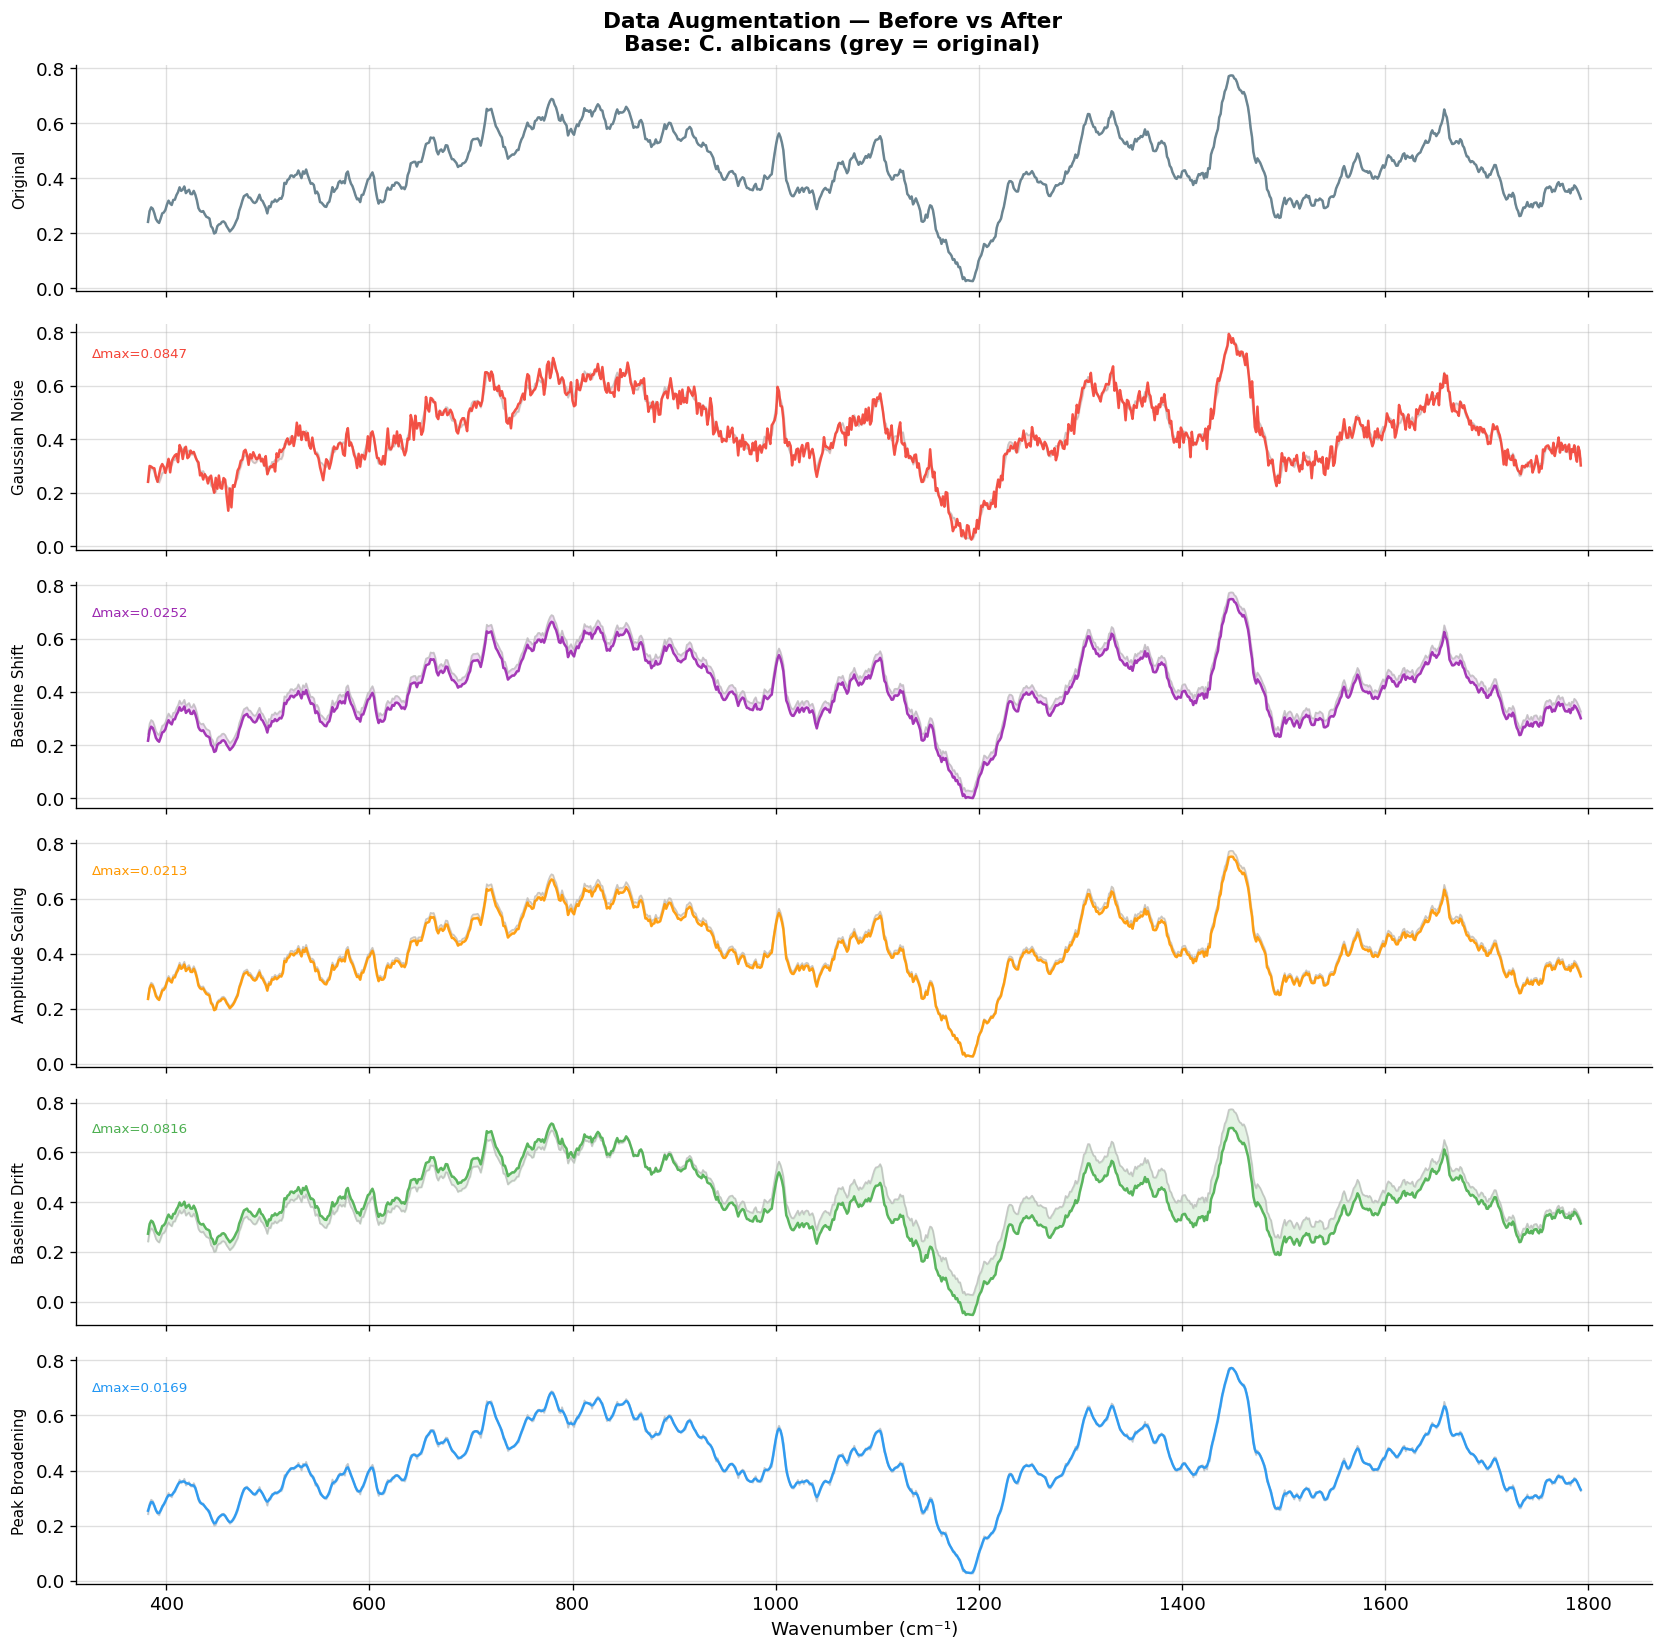

In [18]:
from src.data.augmentation import (
    GaussianNoise,
    BaselineShift,
    AmplitudeScaling,
    BaselineDrift,
    PeakBroadening,
    AugmentationPipeline,
)

rng = np.random.default_rng(42)

# Use the smoothed (post-SG) spectrum as the base for augmentation visualization
base_spectrum = x1[0].copy()  # SG-smoothed, shape (L,)
base_batch = base_spectrum[np.newaxis, :]  # (1, L)

augmentations = [
    ('Original', None),
    ('Gaussian Noise', GaussianNoise(max_std=0.03)),
    ('Baseline Shift', BaselineShift(max_shift=0.08)),
    ('Amplitude Scaling', AmplitudeScaling(factor=0.15)),
    ('Baseline Drift', BaselineDrift(max_strength=0.10, n_control_points=5)),
    ('Peak Broadening', PeakBroadening(max_sigma=1.5)),
]

fig, axes = plt.subplots(len(augmentations), 1, figsize=(14, 14), sharex=True)
AUG_COLORS = ['#607D8B', '#F44336', '#9C27B0', '#FF9800', '#4CAF50', '#2196F3']

for ax, (name, aug), color in zip(axes, augmentations, AUG_COLORS):
    if aug is None:
        spectrum_aug = base_spectrum
    else:
        spectrum_aug = aug(base_batch.copy(), rng)[0]

    ax.plot(wavenumbers, base_spectrum, color='#BDBDBD', linewidth=1.0,
            alpha=0.8, label='Original')
    ax.plot(wavenumbers, spectrum_aug, color=color, linewidth=1.5,
            alpha=0.9, label=name)
    ax.set_ylabel(name, fontsize=9, labelpad=5)
    if name != 'Original':
        diff = spectrum_aug - base_spectrum
        ax.fill_between(wavenumbers, base_spectrum, spectrum_aug,
                        color=color, alpha=0.15)
        ax.text(0.01, 0.85, f'Δmax={abs(diff).max():.4f}',
                transform=ax.transAxes, fontsize=8, color=color)

axes[-1].set_xlabel(wn_label, fontsize=11)
fig.suptitle(f'Data Augmentation — Before vs After\nBase: {strain_name} (grey = original)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
# Demonstrate the full AugmentationPipeline on a batch
aug_pipeline = AugmentationPipeline.from_config(cfg['augmentation'])

print(f"Pipeline steps   : {[type(s).__name__ for s in aug_pipeline.steps]}")
print(f"Apply probability: {aug_pipeline.p}")
print(f"Clip range       : [{aug_pipeline.clip_min}, {aug_pipeline.clip_max}]")

# Apply to a small batch and show effect
X_batch_raw = X_ref[:8].copy()  # 8 raw spectra
aug_pipeline.set_epoch(1)
X_batch_aug = aug_pipeline(X_batch_raw)

print(f"\nBatch shape (in) : {X_batch_raw.shape}")
print(f"Batch shape (out): {X_batch_aug.shape}")
print(f"Max perturbation : {abs(X_batch_aug - X_batch_raw).max():.5f}")

Pipeline steps   : ['GaussianNoise', 'AmplitudeScaling', 'BaselineDrift', 'PeakBroadening', 'SpectralShift']
Apply probability: 0.25
Clip range       : [-3.0, 3.0]

Batch shape (in) : (8, 1000)
Batch shape (out): (8, 1000)
Max perturbation : 0.27720


### 13. Concluding Remarks & Next Steps

This notebook verified the structural integrity of the label ontology, visualized the immense physical domain shift present in the clinical spectra, and demonstrated the rigorous mathematical preprocessing pipeline required to extract biological signals from raw instrument noise.

**Next Step:** Proceed to [Notebook 02 — Train and Evaluate](./02_train_and_evaluate.ipynb) where these `(2, L)` spectral tensors will be ingested by the Temporal Convolutional Network (TCN) through the three-stage transfer learning architecture.

Model input tensor shape: (6, 2, 1000)
  Batch size       : 6
  Channels         : 2  (0=normalized, 1=derivative)
  Spectral length  : 1000
  Channel 0 stats  : mean=-0.0000  std=1.0000
  Channel 1 stats  : mean=-0.0010  std=0.0951


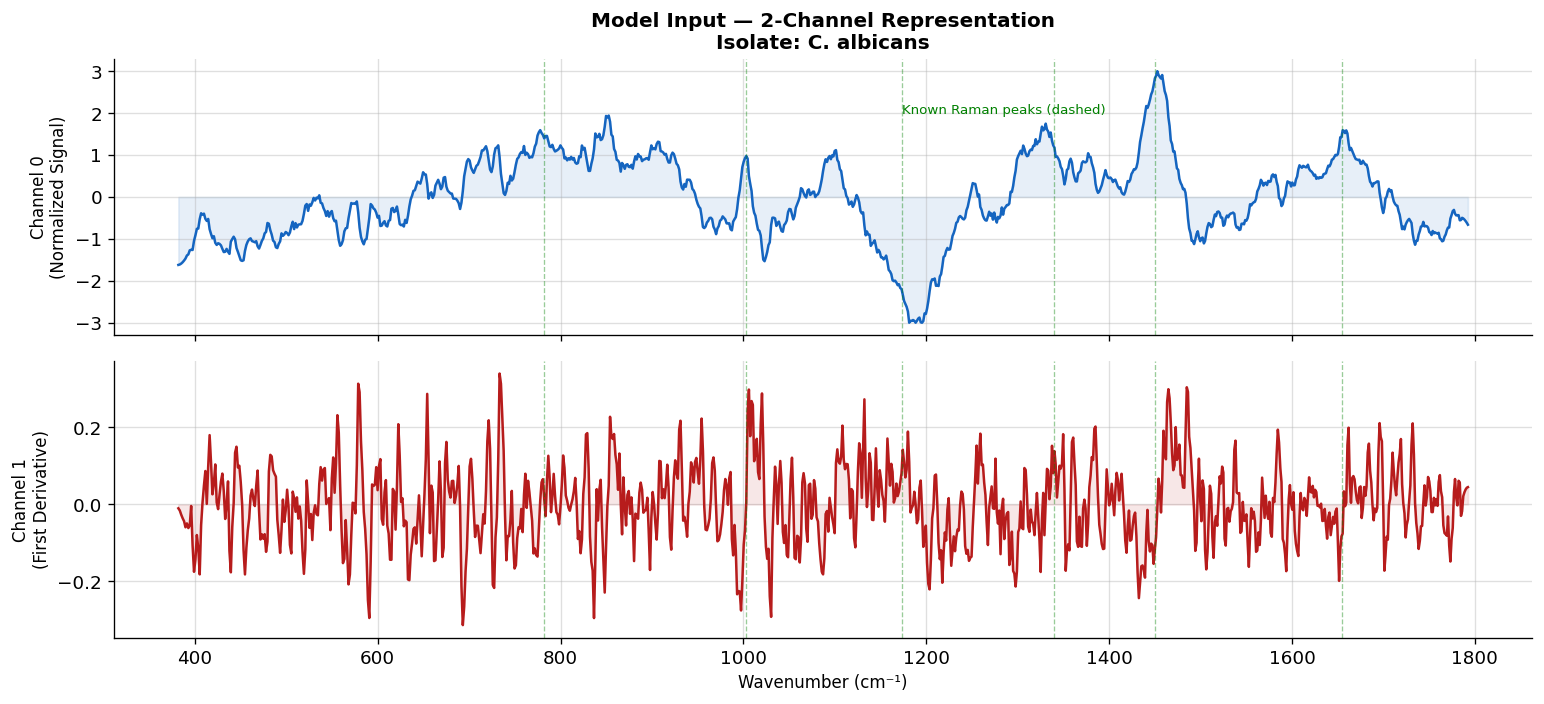

In [20]:
# Process the reference batch through the complete pipeline and visualize
X_processed = preprocessor.transform(X_ref[:6])  # shape (6, 2, L)

print(f"Model input tensor shape: {X_processed.shape}")
print(f"  Batch size       : {X_processed.shape[0]}")
print(f"  Channels         : {X_processed.shape[1]}  (0=normalized, 1=derivative)")
print(f"  Spectral length  : {X_processed.shape[2]}")
print(f"  Channel 0 stats  : mean={X_processed[:, 0, :].mean():.4f}  std={X_processed[:, 0, :].std():.4f}")
print(f"  Channel 1 stats  : mean={X_processed[:, 1, :].mean():.4f}  std={X_processed[:, 1, :].std():.4f}")

# Visualize both channels for one example
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

example = X_processed[0]  # shape (2, L)
isolate_name = ISOLATES[int(y_ref[0])]['strain']

axes[0].plot(wavenumbers, example[0], color='#1565C0', linewidth=1.5)
axes[0].fill_between(wavenumbers, example[0], alpha=0.1, color='#1565C0')
axes[0].set_ylabel('Channel 0\n(Normalized Signal)', fontsize=10)
axes[0].set_title(f'Model Input — 2-Channel Representation\n'
                   f'Isolate: {isolate_name}', fontsize=12, fontweight='bold')

axes[1].plot(wavenumbers, example[1], color='#B71C1C', linewidth=1.5)
axes[1].fill_between(wavenumbers, example[1], alpha=0.1, color='#B71C1C')
axes[1].set_ylabel('Channel 1\n(First Derivative)', fontsize=10)
axes[1].set_xlabel(wn_label, fontsize=10)

# Mark known Raman peaks (approximate positions, publication-relevant)
KNOWN_PEAKS = [782, 1003, 1173, 1340, 1450, 1655]  # cm⁻¹ (approximate)
for peak_wn in KNOWN_PEAKS:
    for ax in axes:
        ax.axvline(x=peak_wn, color='green', alpha=0.4, linewidth=0.8, linestyle='--')

# Annotation for known peaks
axes[0].annotate('Known Raman peaks (dashed)', xy=(KNOWN_PEAKS[2], 0.8),
                  xycoords=('data', 'axes fraction'), fontsize=8, color='green')

plt.tight_layout()
plt.show()

---

## Summary

This notebook characterized the complete data foundation of the pipeline:

| Component | Detail |
|-----------|--------|
| Reference dataset | 30 bacterial/fungal isolates, laboratory-controlled spectra |
| Clinical datasets | 2018 + 2019 patient isolates, 5 treatment classes |
| Label ontology | 30 isolates → 8 global treatments → 5 compact clinical classes |
| Preprocessing | SG smoothing → SNV → SG derivative → clip → 2-channel stack |
| Augmentation | 5 stochastic transforms applied with p=0.5 during training |
| Model input | `(2, L)` tensor per spectrum: normalized signal + first derivative |

**Key insight:** The SNV normalization effectively eliminates the additive baseline domain shift between reference (lab) and clinical (hospital) spectra, enabling transfer without catastrophic forgetting of spectral features.

Proceed to **Notebook 02** for the complete training methodology and benchmark results.